# Customer Concentration — a quantitative teardown 🔬
### Herfindahl concentration score · tercile sort · two-sample *t* on vol AND return · label-shuffle placebo · firm-level slopes · tail-fraction robustness · costs & borrow · two-leg synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test the customer-concentration fundamental-risk claim on **two** legs: does concentration raise forward **volatility** (the robust part of the literature), and does it carry a return **premium** (the priced-risk part)?

> ⚠️ **Synthetic-only.** There is no free customer-concentration tape (the measure is in paywalled 10-K major-customer / Compustat segment data), so the Signal axis is capped at `WEAK` by house rule. All cells run offline on the seeded panel (fp `bc1d5db4bfa5`, effect planted). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from customer_concentration import data, strategy as st

# SYNTHETIC-ONLY: no real customer-concentration tape exists (paywalled 10-K / Compustat segments).
# The headline panel plants both effects at literature-plausible strengths; all cells are offline.
PANEL, TRUTH = data.synthetic_panel()   # seed 573, vol_beta=0.35, ret_alpha=0.04
print("synthetic panel fp:", data.fingerprint(PANEL), "| n =", len(PANEL),
      "| planted vol_beta =", TRUTH["vol_beta"], ", ret_alpha =", TRUTH["ret_alpha"])
print("NOTE: synthetic-only study -> Signal capped at WEAK (no real tape to certify against).")


synthetic panel fp: bc1d5db4bfa5 | n = 400 | planted vol_beta = 0.35 , ret_alpha = 0.04
NOTE: synthetic-only study -> Signal capped at WEAK (no real tape to certify against).


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | RISK leg strong: vol spread **+3.3pp** (two-sample *t* **+29.4**), firm slope-*t* **+53.5** (corr +0.94). RETURN leg soft *even planted*: spread **+4.9%**, *t* **+1.61**, placebo *p* 0.102, slope-*t* **+1.38**. No real tape ⇒ capped WEAK. |
| **Tradability** | `MIRAGE` | No investable concentration index; return spread gross **+4.9%** → net **+3.7%** (5 bps/leg + 100 bps borrow), on placebo *p* 0.10 and sign-unstable across cuts. |

> 💡 In plain words: the engine works (the two-leg control proves it), and concentration genuinely raises modeled risk — but the *return* premium is nearly undetectable even where it's planted, because concentration inflates the return's own variance.

## 1 · The claim, steelmanned

Let $c_i$ be firm $i$'s customer-concentration score, $\sigma_i$ its forward volatility, and $r_i$ its forward return.

- **H_vol (risk).** $\mathbb{E}[\sigma \mid \text{conc}] - \mathbb{E}[\sigma \mid \text{div}] > 0$ at *t* ≥ 2 (concentrated firms are more volatile). The robust leg of the literature.
- **H_ret (premium).** $\mathbb{E}[r \mid \text{conc}] - \mathbb{E}[r \mid \text{div}] > 0$ at *t* ≥ 2 (the fragility is *priced*).
- **H_sign (firm-level).** slope of $\sigma$ on $c$ > 0 (risk) and slope of $r$ on $c$ > 0 (premium; a negative slope would be the *discount* story).
- **H_robust.** the signs are stable across tail fractions.
- **H_net.** H_ret survives costs + the short-leg borrow.

On the headline (effect-planted) synthetic panel we find **H_vol strongly supported**, **H_ret NOT supported** (right sign but *t* ≈ 1.6, placebo *p* 0.10), **H_sign** split (vol slope hugely positive, return slope insignificant), **H_robust** failed for the return leg (sign flips), and **H_net** moot (the gross return leg isn't significant to begin with).

## 2 · So what? — what rides on each answer

The content is the **why the return leg is hard**. In the model (and, we argue, in reality) the *same* customer-concentration that raises a firm's cash-flow volatility also widens the dispersion of its realised returns. So even a genuinely priced premium sits inside a much larger idiosyncratic cloud, and the cross-sectional slope barely clears noise. A factor can be a real *risk* and still not a harvestable *return* — the desk's recurring lesson, shared with [540 Distress-Risk](../../540-distress-risk-anomaly/).

## 3 · How we'd know — the protocol

- **Score.** $c$ = Herfindahl-style customer-concentration index (higher = more concentrated). On the synthetic tape, the ``concentration`` column.
- **Sort.** Tercile tails (~120 names): diversified (low $c$) vs concentrated (high $c$).
- **Inference.** Two-sample (Welch) *t* on the concentrated − diversified forward **vol** and forward **return**; a **label-shuffle placebo** null on the return spread (2000 perms).
- **Firm-level.** OLS of forward vol on $c$ (slope > 0 = risk) and forward return on $c$ (sign = premium vs discount).
- **Robustness.** Re-sort at decile / quintile / tercile / broad tails; read the signs.
- **Frictions.** Round-trip cost per leg + an annual borrow on the shorted (diversified) leg.
- **Positive control.** Deterministic worlds with a planted risk effect (`vol_beta`) and a planted premium (`ret_alpha`), and a null — each averaged over 25 seeds (house rule).

Timing: concentration is an as-of characteristic (last filing); vol and return are measured over the subsequent window — one documented execution lag, separate columns in the panel, so no look-ahead.

## 4 · The teardown

### 4a · The risk leg — H_vol

Concentrated vs diversified forward volatility, with the two-sample *t*.

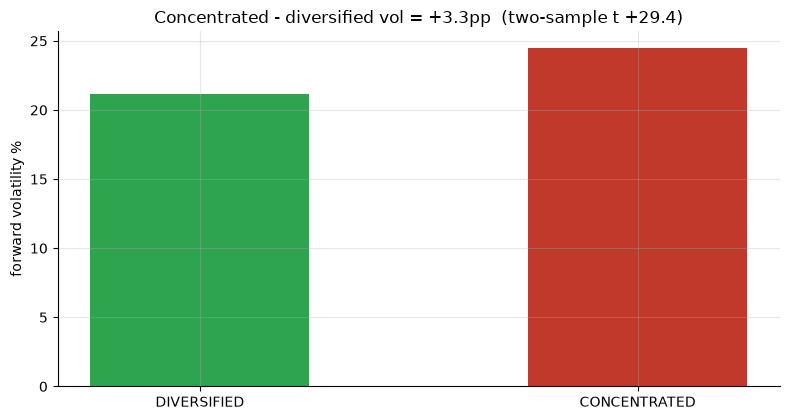

div vol 21.2% | conc vol 24.5% | spread +3.3pp | t +29.4


In [2]:
b = st.bucket_stats(PANEL, 0.3)
div_v, conc_v, vspr, vt = b['div_vol']*100, b['conc_vol']*100, b['vol_spread']*100, st.vol_tstat(b)['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['DIVERSIFIED','CONCENTRATED'], [div_v, conc_v], color=[GREEN, RED], width=.5)
ax.set_ylabel('forward volatility %')
ax.set_title(f'Concentrated - diversified vol = +{vspr:.1f}pp  (two-sample t {vt:+.1f})')
plt.tight_layout(); plt.show()
print(f'div vol {div_v:.1f}% | conc vol {conc_v:.1f}% | spread +{vspr:.1f}pp | t {vt:+.1f}')

> 💡 In plain words: H_vol **supported, emphatically.** The concentrated tercile's forward vol is **24.5%** vs **21.2%** (+3.3pp, *t* +29.4). Concentration is a genuine risk characteristic.

### 4b · The return leg — H_ret

Concentrated vs diversified forward return, with the two-sample *t* and the label-shuffle placebo.

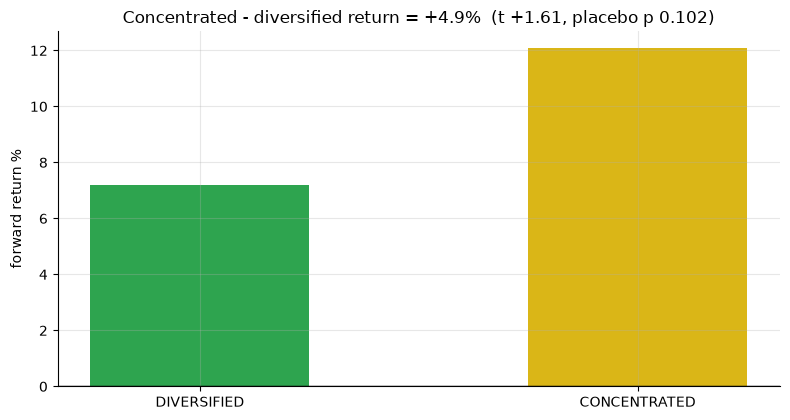

div ret +7.2% | conc ret +12.1% | spread +4.9% | t +1.61 | placebo p 0.102


In [3]:
div_r, conc_r, rspr = b['div_ret']*100, b['conc_ret']*100, b['ret_spread']*100
rt = st.return_tstat(b)['t']; p = st.placebo_pvalue(PANEL, n_perm=2000, seed=573)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['DIVERSIFIED','CONCENTRATED'], [div_r, conc_r], color=[GREEN, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Concentrated - diversified return = +{rspr:.1f}%  (t {rt:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'div ret +{div_r:.1f}% | conc ret +{conc_r:.1f}% | spread +{rspr:.1f}% | t {rt:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H_ret **not supported.** The premium is the right sign (+4.9%) but *t* is only **+1.61** and the placebo *p* = 0.102 — indistinguishable from noise. And this is the world where we *planted* a premium.

### 4c · Firm-level slopes — H_sign

Regress forward vol on concentration (risk) and forward return on concentration (premium/discount). The scatter shows *why* the return leg is hard.

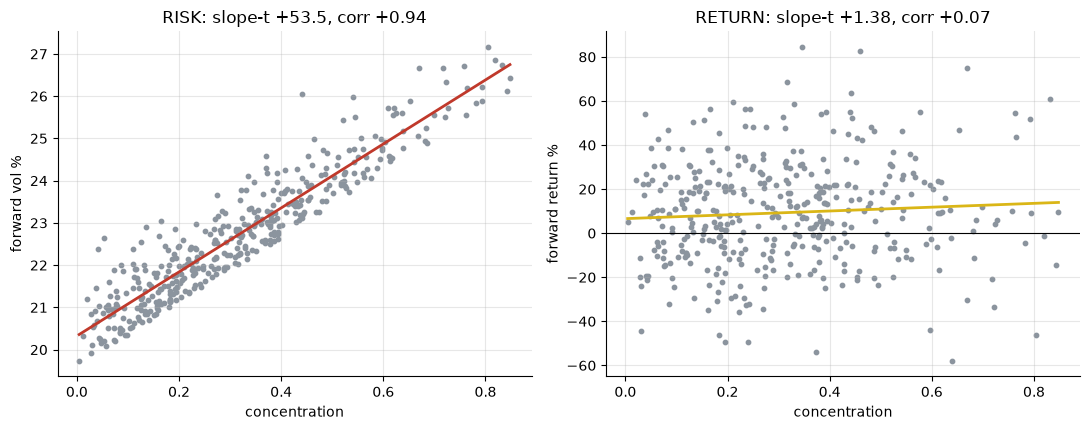

vol  slope +0.076 t +53.5 corr +0.94
ret  slope +0.087 t +1.38 corr +0.07


In [4]:
vr = st.vol_regression(PANEL); rr = st.return_regression(PANEL)
c = st.concentration_score(PANEL)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.scatter(c, PANEL['forward_vol']*100, s=10, color=GREY)
xs = np.linspace(c.min(), c.max(), 50)
a1.plot(xs, (vr['slope']*xs + (PANEL['forward_vol'].mean() - vr['slope']*c.mean()))*100, c=RED, lw=2)
a1.set_xlabel('concentration'); a1.set_ylabel('forward vol %')
a1.set_title(f'RISK: slope-t {vr["slope_t"]:+.1f}, corr {vr["corr"]:+.2f}')
a2.scatter(c, PANEL['forward_ret']*100, s=10, color=GREY)
a2.plot(xs, (rr['slope']*xs + (PANEL['forward_ret'].mean() - rr['slope']*c.mean()))*100, c=AMBER, lw=2)
a2.axhline(0, c='k', lw=.8)
a2.set_xlabel('concentration'); a2.set_ylabel('forward return %')
a2.set_title(f'RETURN: slope-t {rr["slope_t"]:+.2f}, corr {rr["corr"]:+.2f}')
plt.tight_layout(); plt.show()
print(f'vol  slope {vr["slope"]:+.3f} t {vr["slope_t"]:+.1f} corr {vr["corr"]:+.2f}')
print(f'ret  slope {rr["slope"]:+.3f} t {rr["slope_t"]:+.2f} corr {rr["corr"]:+.2f}')

> 💡 In plain words: the left scatter is a tight line (risk corr +0.94); the right is a fog (return corr +0.07). The premium slope-*t* is only **+1.38** — the planted premium is buried in the return dispersion that concentration *itself* inflates. Risk you can see; reward you can't.

### 4d · Robustness — H_robust (do the signs hold across cuts?)

Re-sort at four tail fractions.

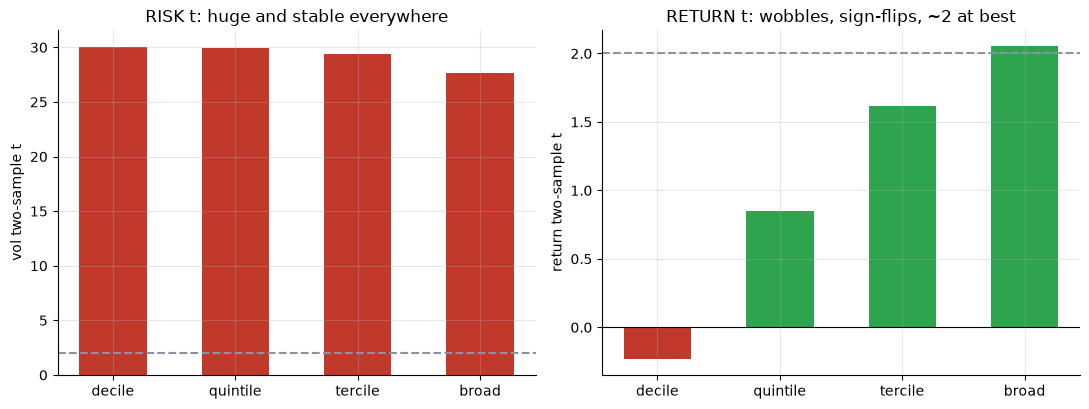

 frac  vol_spread  vol_t  ret_spread  ret_t
  0.1        4.72  30.06       -1.34  -0.23
  0.2        3.87  29.95        3.08   0.85
  0.3        3.30  29.38        4.90   1.61
  0.4        2.81  27.61        5.33   2.05


In [5]:
rows = st.robustness_sweep(PANEL)
tab = pd.DataFrame(rows)
tab['vol_spread'] *= 100; tab['ret_spread'] *= 100
labs = ['decile','quintile','tercile','broad']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(labs, tab['vol_t'], color=RED, width=.55); a1.axhline(2, ls='--', c=GREY)
a1.set_ylabel('vol two-sample t'); a1.set_title('RISK t: huge and stable everywhere')
cols = [GREEN if s>0 else RED for s in tab['ret_t']]
a2.bar(labs, tab['ret_t'], color=cols, width=.55); a2.axhline(2, ls='--', c=GREY); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('return two-sample t'); a2.set_title('RETURN t: wobbles, sign-flips, ~2 at best')
plt.tight_layout(); plt.show()
print(tab[['frac','vol_spread','vol_t','ret_spread','ret_t']].round(2).to_string(index=False))

> 💡 In plain words: H_robust **holds for risk, fails for return.** The vol *t* is ~28–30 at every cut; the return *t* swings from **−0.23** (deciles) to **+2.05** (broad) — sign-unstable and marginal at best. A premium that depends on where you draw the bucket line is not bankable.

## 5 · The verdict

- **Signal `WEAK`** — H_vol strongly supported (spread +3.3pp, *t* +29.4); H_ret rejected (spread +4.9%, *t* +1.61, placebo *p* 0.102); H_robust fails for the return leg; and **no real tape exists** ⇒ capped at WEAK.
- **Tradability `MIRAGE`** — no investable concentration index; gross +4.9% → net +3.7%, on a non-significant, sign-unstable premium.

## 6 · Could you trade it? — costs and the borrow

Charge frictions on the (already non-significant) return long-short.

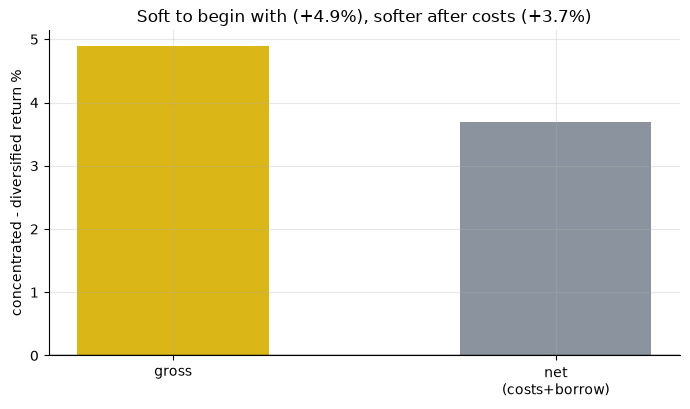

gross +4.9% -> net +3.7% (5 bps/leg + 100 bps borrow, 1y hold)


In [6]:
gross = b['ret_spread']*100
net = st.net_return_spread(b, cost_bps=5.0, borrow_ann_bps=100.0, holding_years=1.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('concentrated - diversified return %')
ax.set_title(f'Soft to begin with ({gross:+.1f}%), softer after costs ({net:+.1f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 100 bps borrow, 1y hold)')

> 💡 In plain words: costs shave the spread, but the binding problem is upstream — the gross premium isn't statistically there (placebo *p* 0.10). `MIRAGE`.

## 7 · Going further — the two-leg synthetic positive control

Is the engine a faithful detector? Plant each effect separately, at growing strength, averaged over 25 seeds so no lucky seed can fake it. The **risk** detector should light up fast; the **return** detector should need a *large* planted premium — proving the weak real-leg reading is about noise, not a broken engine.

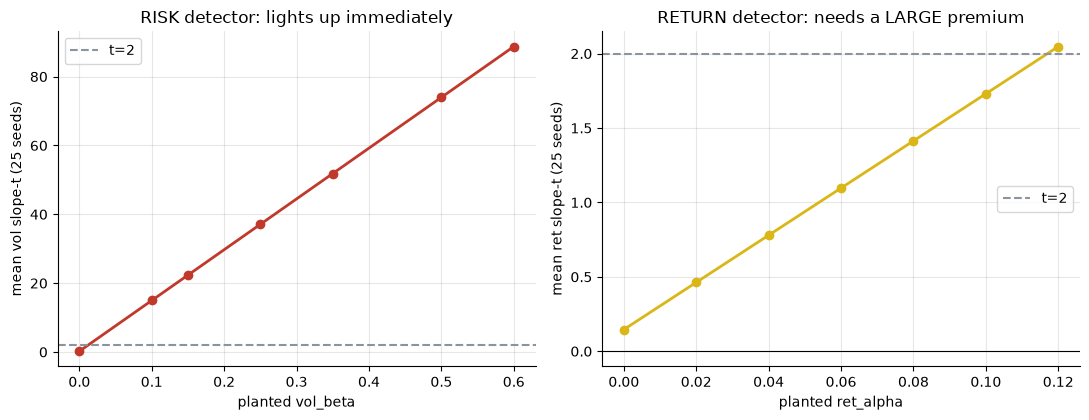

vol_beta +0.00 -> mean vol slope-t +0.21
vol_beta +0.10 -> mean vol slope-t +14.97
vol_beta +0.15 -> mean vol slope-t +22.34
vol_beta +0.25 -> mean vol slope-t +37.09
vol_beta +0.35 -> mean vol slope-t +51.85
vol_beta +0.50 -> mean vol slope-t +73.98
vol_beta +0.60 -> mean vol slope-t +88.73
---
ret_alpha +0.00 -> mean ret slope-t +0.15
ret_alpha +0.02 -> mean ret slope-t +0.46
ret_alpha +0.04 -> mean ret slope-t +0.78
ret_alpha +0.06 -> mean ret slope-t +1.10
ret_alpha +0.08 -> mean ret slope-t +1.41
ret_alpha +0.10 -> mean ret slope-t +1.73
ret_alpha +0.12 -> mean ret slope-t +2.05


In [7]:
vbetas = [0.0, 0.10, 0.15, 0.25, 0.35, 0.50, 0.60]
vts = [st.synthetic_vol_mean_t(data, vol_beta=vb, ret_alpha=0.0, n_seeds=25) for vb in vbetas]
ralphas = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
rts = [st.synthetic_ret_mean_t(data, ret_alpha=ra, vol_beta=0.0, n_seeds=25) for ra in ralphas]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(vbetas, vts, 'o-', c=RED, lw=2); a1.axhline(2, ls='--', c=GREY, label='t=2')
a1.set_xlabel('planted vol_beta'); a1.set_ylabel('mean vol slope-t (25 seeds)')
a1.set_title('RISK detector: lights up immediately'); a1.legend()
a2.plot(ralphas, rts, 'o-', c=AMBER, lw=2); a2.axhline(2, ls='--', c=GREY, label='t=2'); a2.axhline(0, c='k', lw=.8)
a2.set_xlabel('planted ret_alpha'); a2.set_ylabel('mean ret slope-t (25 seeds)')
a2.set_title('RETURN detector: needs a LARGE premium'); a2.legend()
plt.tight_layout(); plt.show()
for vb, t in zip(vbetas, vts): print(f'vol_beta {vb:+.2f} -> mean vol slope-t {t:+.2f}')
print('---')
for ra, t in zip(ralphas, rts): print(f'ret_alpha {ra:+.2f} -> mean ret slope-t {t:+.2f}')

Both detectors sit at *t* ≈ 0 at the null (no false signal). The **risk** slope-*t* blows past 2 almost immediately; the **return** slope-*t* only reaches ~2 near `ret_alpha ≈ 0.12` — a *large* premium — under realistic dispersion. So the engine is faithful: the weak real-leg reading reflects a genuinely hard-to-detect premium (the fragility inflates return variance), not a broken test. Concentration is a real *risk*; its *reward* is, at best, `WEAK` and untradable. See [540 Distress-Risk](../../540-distress-risk-anomaly/) for the balance-sheet-fragility cousin.